# Visium HD FFPE (probe) Part I

This notebook is the first of two tutorials where we apply SPLISOSM to a **probe-based Visium HD FFPE dataset** of adult mouse brain. It covers the following steps:

1. Load probe-level quantification from Space Ranger outputs.
2. Run FFT-accelerated spatial variability tests with `SplisosmFFT`.
3. Compare SV test results across spatial resolutions.
4. Compare `SplisosmFFT` and `SplisosmNP` results.

Next step: [Visium HD FFPE (probe) Part II](visiumhd_ffpe_du.ipynb) for differential usage analysis to find potential **RNA-binding protein (RBP)** regulators of genes with spatially variable isoform/peak/exon/junction usage. For advanced users: [SV hyperparameter optimization](visiumhd_ffpe_svhp.ipynb) for comparing effects of kernel hyperparameters and low-rank approximation on SV test results.

The workflow is compatible with other ST platforms. See [guidance on data preparation](../txquant.rst) and the [tutorial gallery](gallery.rst) for more examples.

Estimated runtime: ~10 min.

## Preliminary notes

For FFPE samples, Visium HD uses pre-designed probes targeting specific transcript regions (such as exons and splice junctions) for sequencing and quantification. After running the [Space Ranger count pipeline (**v4.0+**)](https://www.10xgenomics.com/support/software/space-ranger/latest/analysis/running-pipelines/count-visium-hd), a `raw_probe_bc_matrix.h5` file containing the barcode-by-probe UMI count matrix is generated at a 2 µm resolution (see the [10x official documentation on output structures](https://www.10xgenomics.com/support/software/space-ranger/latest/analysis/outputs/output-overview#hd-outputs)). We will load this matrix, along with the corresponding gene-expression matrices, into a [SpatialData](https://spatialdata.scverse.org/en/stable/) object to perform SPLISOSM's spatial variability (SV) tests.

SPLISOSM offers two implementations for its HSIC-based dependency tests:
- `SplisosmFFT`: Uses Fast Fourier Transform (FFT) for stationary kernels with periodic boundary conditions. It is the fastest path for regular grids, such as Visium HD bins.
- `SplisosmNP`: Uses a sparse CAR kernel with open boundary conditions. It works with any geometry, including cell-segmented data.

**Note:** Since `v1.2.0`, the low-rank approximation `SplisosmNP` path has been deprecated. The new implementation uses direct cumulant estimates from the full-rank kernel matrix. See the [Methods page](../methods.rst) for details. Also, check out the [SV hyperparameter optimization notebook](visiumhd_ffpe_svhp.ipynb) for comparison with the legacy low-rank approach.

## Imports

In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import warnings

import annsel as an
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import spatialdata as sd
import spatialdata_plot
from spatialdata import rasterize_bins

from splisosm import SplisosmFFT, SplisosmNP
from splisosm.utils import counts_to_ratios
from splisosm.io import load_visiumhd_probe

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (6, 4)

## Configure paths and core parameters

In [3]:
# Required: Space Ranger `outs` directory for Visium HD
visium_hd_outs = Path("/path/to/visium_hd_ffpe/outs")

# Optional cache path for faster reruns
sdata_zarr = visium_hd_outs / "sdata_probe.filtered.zarr"

# Spatial resolutions (µm) to materialize in SpatialData
bin_sizes = [2, 8, 16]

# Dataset and table identifiers (16µm binning used throughout)
dataset_id = "Visium_HD_Mouse_Brain"
test_table = "square_016um"
test_bins_element = f"{dataset_id}_square_016um"

# Probe annotation column names
group_iso_by = "gene_ids"
candidate_gene_name_cols = ["gene_name", "gene_symbol", "gene_names"]

# Probe QC filters
min_counts = 10
min_bin_pct = 0.01

In [4]:
# local path
visium_hd_outs = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ffpe_mouse_cbs/")
sdata_zarr = visium_hd_outs / "sdata_probe.filtered.zarr"
reference_path = Path("/Users/jysumac/reference/mm39/")

## Load probe-level `SpatialData`

To run the analysis, please download the Space Ranger `outs` directory for the [Visium HD adult mouse brain FFPE dataset](https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-mouse-brain-he-v4) from 10x Genomics ([Visium Mouse Transcriptome Probe Set v2.1](https://www.10xgenomics.com/support/cytassist-spatial-gene-expression/documentation/steps/probe-sets/visium-mouse-transcriptome-probe-set-v2-1)). 

We use `splisosm.io.load_visiumhd_probe` to load data as a `SpatialData` object. The function wraps [`spatialdata-io.visium_hd`](https://spatialdata.scverse.org/projects/io/en/latest/generated/spatialdata_io.visium_hd.html). Setting `filtered_counts_file=True` keeps only barcodes that pass Space Ranger's filtering (i.e., non-background bins retained in `filtered_feature_bc_matrix`).

In [5]:
%%time
if sdata_zarr.exists():
    print("Loading cached SpatialData...")
    sdata = sd.read_zarr(sdata_zarr)
else:
    print("Building probe-level SpatialData from Space Ranger outputs...")
    sdata = load_visiumhd_probe(
        path=visium_hd_outs,
        bin_sizes=bin_sizes,
        filtered_counts_file=True,
        load_all_images=False,
        var_names_make_unique=True,
        counts_layer_name="counts",
    )
    # Optional: cache for future runs
    # sdata.write(sdata_zarr)

sdata

Loading cached SpatialData...
CPU times: user 8.05 s, sys: 1.61 s, total: 9.66 s
Wall time: 5.71 s


SpatialData object, with associated Zarr store: /Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ffpe_mouse_cbs/sdata_probe.filtered.zarr
├── Images
│     ├── 'Visium_HD_Mouse_Brain_full_image': DataTree[cyx] (3, 23947, 18872), (3, 11973, 9436), (3, 5986, 4718), (3, 2993, 2359), (3, 1496, 1179)
│     ├── 'Visium_HD_Mouse_Brain_hires_image': DataArray[cyx] (3, 6000, 4729)
│     └── 'Visium_HD_Mouse_Brain_lowres_image': DataArray[cyx] (3, 600, 473)
├── Shapes
│     ├── 'Visium_HD_Mouse_Brain_cell_segmentations': GeoDataFrame shape: (40222, 2) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_002um': GeoDataFrame shape: (6296688, 1) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_008um': GeoDataFrame shape: (393543, 1) (2D shapes)
│     └── 'Visium_HD_Mouse_Brain_square_016um': GeoDataFrame shape: (98917, 1) (2D shapes)
└── Tables
      ├── 'cell_segmentations': AnnData (40222, 55538)
      ├── 'square_002um': AnnData (6296688, 55538)
      ├── 'square_008um': AnnData (393543, 5

SPLISOSM can be run at any spatial resolution, but data become sparser at finer scales.

In [6]:
def summarize_table(adata):
    X = adata.layers["counts"] if "counts" in adata.layers else adata.X
    if hasattr(X, "nnz"):
        nnz = int(X.nnz)
        total = int(X.shape[0] * X.shape[1])
        density = nnz / total if total else np.nan
    else:
        arr = np.asarray(X)
        nnz = int(np.count_nonzero(arr))
        total = int(arr.size)
        density = nnz / total if total else np.nan
    return {
        "n_probes": int(adata.n_vars),
        "n_bins": int(adata.n_obs),
        "count_mtx_density": density,
    }

rows = []
for key in sorted(sdata.tables.keys()):
    if key.startswith("square_"):
        rows.append({"table": key, **summarize_table(sdata.tables[key])})

table_summary = pd.DataFrame(rows).sort_values("table")
table_summary

,table,n_probes,n_bins,count_mtx_density
0,square_002um,55538,6296688,0.000253
1,square_008um,55538,393543,0.003819
2,square_016um,55538,98917,0.013923


To balance sparsity and computation, we recommend `16µm` or `8µm` bins for initial analysis. Resolution comparison is shown at the end of this notebook.

In [7]:
# Optional: inspect available coordinate systems and image/shape keys
print("Tables:", sorted(sdata.tables.keys()))
print("Images:", sorted(getattr(sdata, "images", {}).keys()))
print("Shapes:", sorted(getattr(sdata, "shapes", {}).keys()))

# Quick guardrails before model setup
if test_table not in sdata.tables:
    raise ValueError(f"{test_table} is not available. Choose from: {sorted(sdata.tables.keys())}")

adata_test = sdata.tables[test_table]
if group_iso_by not in adata_test.var.columns:
    raise ValueError(f"{group_iso_by} not found in {test_table}.var columns")

gene_name_col = None
for col in candidate_gene_name_cols:
    if col in adata_test.var.columns:
        gene_name_col = col
        break

print(f"Using table={test_table}, bins={test_bins_element}")
print(f"Grouping column={group_iso_by}, display names={gene_name_col}")

Tables: ['cell_segmentations', 'square_002um', 'square_008um', 'square_016um']
Images: ['Visium_HD_Mouse_Brain_full_image', 'Visium_HD_Mouse_Brain_hires_image', 'Visium_HD_Mouse_Brain_lowres_image']
Shapes: ['Visium_HD_Mouse_Brain_cell_segmentations', 'Visium_HD_Mouse_Brain_square_002um', 'Visium_HD_Mouse_Brain_square_008um', 'Visium_HD_Mouse_Brain_square_016um']
Using table=square_016um, bins=Visium_HD_Mouse_Brain_square_016um
Grouping column=gene_ids, display names=gene_name


Use `spatialdata-plot` to visualize tissue morphology:

CPU times: user 2.16 s, sys: 218 ms, total: 2.38 s
Wall time: 2.84 s


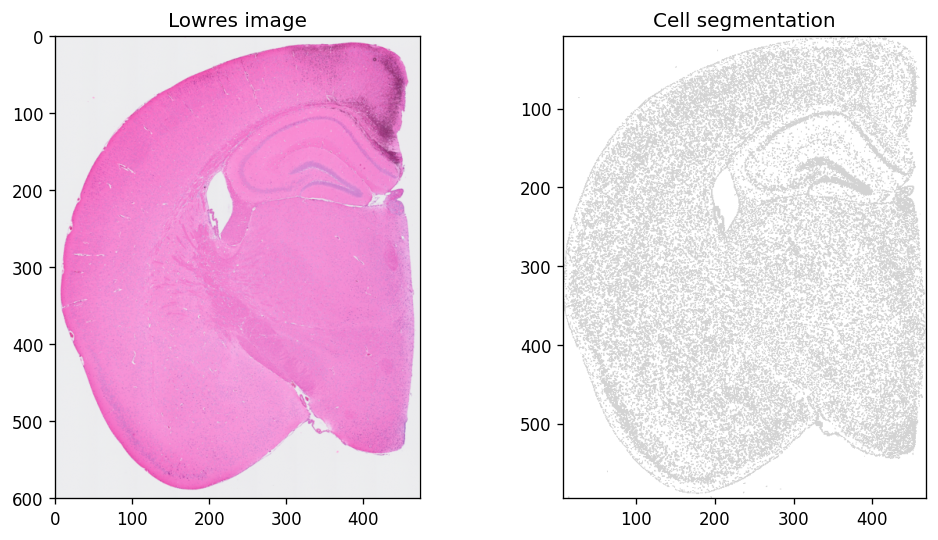

In [8]:
%%time
axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_images(f"{dataset_id}_lowres_image").pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[0], title="Lowres image"
)
sdata.pl.render_shapes(f"{dataset_id}_cell_segmentations").pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[1], title="Cell segmentation"
)

To visualize probe expression as an image, rasterize the spatial bins first:

In [9]:
%%time
for bin_size in ["016", "008", "002"]:
    # rasterize_bins() requires a compressed sparse column (csc) matrix
    sdata.tables[f"square_{bin_size}um"].X = sdata.tables[f"square_{bin_size}um"].X.tocsc()
    rasterized = rasterize_bins(
        sdata,
        f"{dataset_id}_square_{bin_size}um",
        f"square_{bin_size}um",
        "array_col",
        "array_row",
    )
    sdata[f"rasterized_{bin_size}um"] = rasterized

CPU times: user 4.54 s, sys: 977 ms, total: 5.52 s
Wall time: 5.91 s


Then visualize a probe's global expression at 16µm resolution:

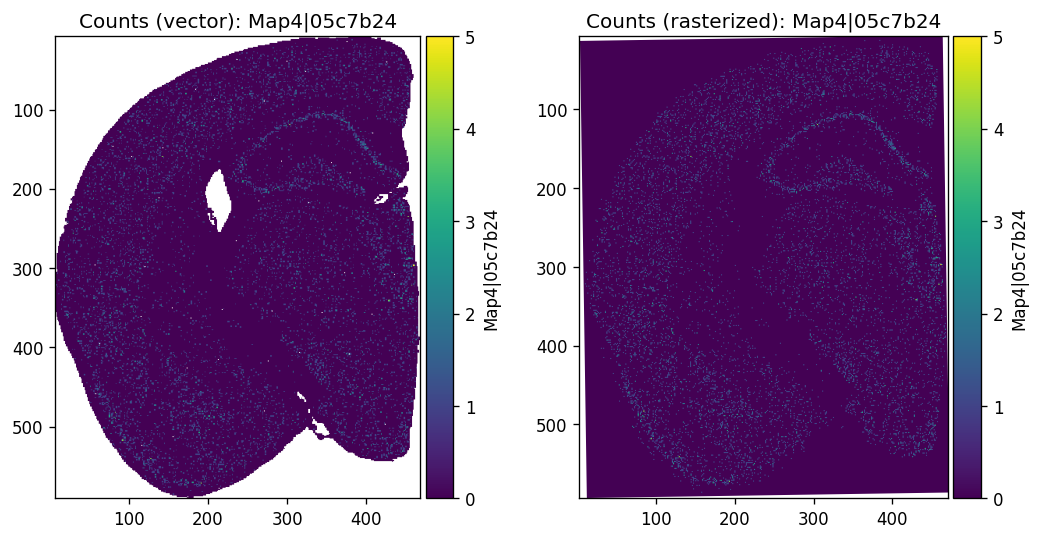

CPU times: user 6.57 s, sys: 1.83 s, total: 8.41 s
Wall time: 9.05 s


In [10]:
%%time
probe_name = "Map4|05c7b24"
axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_shapes(f"{dataset_id}_square_016um", color=probe_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[0], title=f"Counts (vector): {probe_name}"
)
sdata.pl.render_images(f"rasterized_016um", channel=probe_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[1], title=f"Counts (rasterized): {probe_name}"
)
plt.subplots_adjust(wspace=0.3)
plt.show()

Or a zoomed-in view at a subregion (2µm resolution):

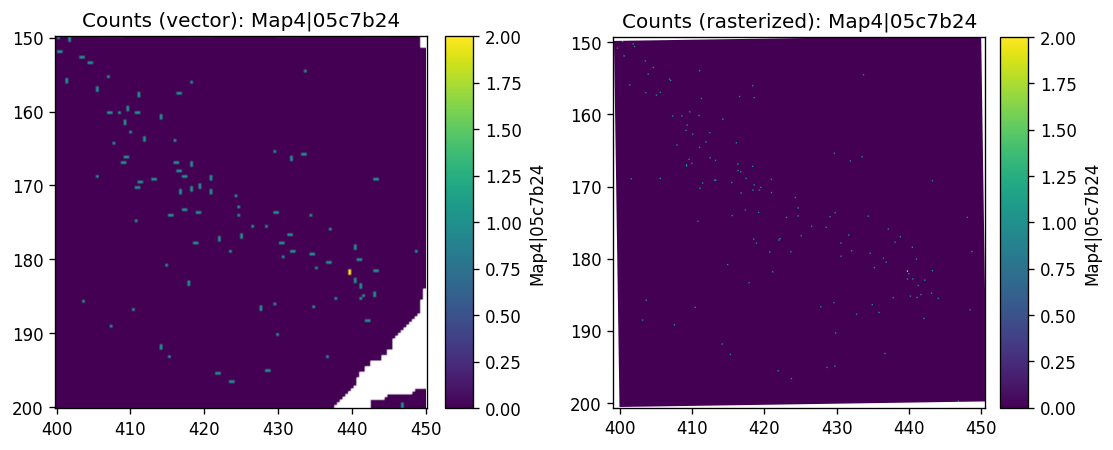

CPU times: user 3.57 s, sys: 639 ms, total: 4.21 s
Wall time: 4.23 s


In [11]:
%%time
sdata_small = sdata.query.bounding_box(
    min_coordinate=[400, 150],
    max_coordinate=[450, 200],
    axes=("x", "y"),
    target_coordinate_system=f"{dataset_id}_downscaled_lowres",
)

axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata_small.pl.render_shapes(f"{dataset_id}_square_002um", color=probe_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[0], title=f"Counts (vector): {probe_name}"
)
sdata_small.pl.render_images(f"rasterized_002um", channel=probe_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[1], title=f"Counts (rasterized): {probe_name}"
)
plt.subplots_adjust(wspace=0.5)
plt.show()

## Spatial variability testing with `SplisosmFFT`

To detect probe usage variation within a given gene, we run spatial variability test using `hsic-ir`.

### Filtering and model setup

Probe filtering criteria:
- `min_counts`: minimum total UMI count across all bins.
- `min_bin_pct`: minimum fraction of bins in which a probe must be detected.
- Genes with fewer than two passing probes are automatically excluded.

In [12]:
model = SplisosmFFT(
    neighbor_degree=1, # for rectangular bins, 1st degree = 4 nearest neighbors
    rho=0.99
)
model.setup_data(
    sdata=sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key="array_col",
    row_key="array_row",
    layer="counts",
    group_iso_by=group_iso_by,
    gene_names=gene_name_col, # 'gene_name'
    # optional probe filtering
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True
)
model

=== SplisosmFFT
- Number of genes: 6224
- Number of spots: 98917
- Number of spots after rasterization: 124344
- Number of covariates: 0
- Average isoforms per gene: 2.7
=== Model configurations
- Neighborhood degree: 1
- Spatial autocorrelation rho: 0.99
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

Extract gene-level summary statistics:

In [13]:
%%time
gene_meta = model.extract_feature_summary(level='gene')
gene_meta.sort_values('perplexity', ascending=False).head(5)

Genes: 100%|██████████| 6224/6224 [00:03<00:00, 1763.08it/s]


CPU times: user 3.91 s, sys: 199 ms, total: 4.11 s
Wall time: 4.13 s


,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
gene,,,,,,
Lrp1b,9,6.876322,0.204121,0.297128,0.723107,0.373754
Shank3,6,5.873075,0.228313,0.283612,0.582347,0.207386
Dusp3,6,5.868889,0.145162,0.171143,0.451044,0.223345
Auts2,6,5.863693,0.142402,0.176431,0.486012,0.222840
Mrtfb,6,5.777855,0.091410,0.104815,0.354134,0.235050


Probe-level summary is also available:

In [14]:
probe_meta = model.extract_feature_summary(level='isoform')
probe_meta.sort_values('gene_name', ascending=False).head(5)

,gene_ids,probe_ids,feature_types,filtered_probes,gene_name,genome,probe_region,pct_bin_on,count_total,count_avg,count_std,ratio_total,ratio_avg,ratio_std
Zzz3|e6db6c7,ENSMUSG00000039068,ENSMUSG00000039068|Zzz3|e6db6c7,Gene Expression,True,Zzz3,GRCm39,unspliced,0.010160,1021.0,0.010322,0.102658,0.313671,0.314407,0.460947
Zzz3|78e9dcb,ENSMUSG00000039068,ENSMUSG00000039068|Zzz3|78e9dcb,Gene Expression,True,Zzz3,GRCm39,unspliced,0.011302,1141.0,0.011535,0.108935,0.350538,0.350133,0.473619
Zzz3|208a79a,ENSMUSG00000039068,ENSMUSG00000039068|Zzz3|208a79a,Gene Expression,True,Zzz3,GRCm39,unspliced,0.010787,1093.0,0.011050,0.107114,0.335791,0.335460,0.469648
Zyx|7e650fc,ENSMUSG00000029860,ENSMUSG00000029860|Zyx|7e650fc,Gene Expression,True,Zyx,GRCm39,unspliced,0.013183,1339.0,0.013537,0.118664,0.504902,0.507246,0.495824
Zyx|680c694,ENSMUSG00000029860,ENSMUSG00000029860|Zyx|680c694,Gene Expression,True,Zyx,GRCm39,spliced,0.012819,1313.0,0.013274,0.118524,0.495098,0.492754,0.495824


### Running HSIC-IR test

In [15]:
%%time

model.test_spatial_variability(
    method="hsic-ir",
    ratio_transformation="none",
    n_jobs=-1,
    print_progress=True,
)
sv_res_16um = model.get_formatted_test_results(
    "sv", with_gene_summary=True
).sort_values("pvalue_adj")

SV [hsic-ir]: 100%|██████████| 551/551 [00:25<00:00, 21.87it/s]


CPU times: user 1min 24s, sys: 19.6 s, total: 1min 44s
Wall time: 25.8 s


Top genes, sorted by adjusted p-value:

In [16]:
sig_001 = int((sv_res_16um["pvalue_adj"] < 0.01).sum())
print(
    "Spatially variably processed genes (FDR < 0.01, 16 µm): "
    f"{sig_001} out of {sv_res_16um.shape[0]} total genes"
)
sv_res_16um.head(5)

Spatially variably processed genes (FDR < 0.01, 16 µm): 196 out of 6226 total genes


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
3964,Syt1,0.000003,0.000000e+00,0.000000e+00,3,2.628424,0.387153,0.758151,1.310308,0.584887
3517,Map4,0.000005,0.000000e+00,0.000000e+00,6,5.579242,0.347968,0.494172,0.839410,0.268749
1805,Gabbr1,0.000003,1.127522e-258,2.339232e-255,6,5.344769,0.283450,0.401003,0.768475,0.262467
1463,Oxr1,0.000002,1.331162e-135,2.071288e-132,5,4.394658,0.203888,0.274887,0.630308,0.306204
2276,Rabgap1l,0.000003,1.409530e-81,1.754583e-78,6,5.325925,0.242779,0.335079,0.701223,0.279439


## Visualize significant events

The helper below renders per-probe **log1p counts** and **within-gene ratios** on the testing grid.

In [17]:
def ensure_rasterized(sdata, bin_table: str, bin_element: str, layer: str = "counts"):
    raster_key = f"rasterized_{bin_table}_{layer}"
    if raster_key in sdata.images:
        return raster_key

    adata = sdata.tables[bin_table]
    adata.X = adata.layers[layer]
    if hasattr(adata.X, "tocsc") and getattr(adata.X, "format", None) != "csc":
        adata.X = adata.X.tocsc()

    sdata[raster_key] = rasterize_bins(
        sdata,
        bins=bin_element,
        table_name=bin_table,
        col_key="array_col",
        row_key="array_row",
    )
    return raster_key

The plotting function checks probe availability, lazily rasterizes data on demand, computes log1p counts and within-gene ratios, and optionally masks zero values.

In [18]:
def plot_gene_probe_maps(
    sdata,
    bin_table: str,
    bin_element: str,
    gene_id: str,
    probe_meta: pd.DataFrame | None = None,
    group_col: str = "gene_ids",
    max_probes: int = 4,
    hide_zero_count: bool = True,
    hide_zero_ratio: bool = True,
):
    adata = sdata.tables[bin_table]
    if probe_meta is None:
        probe_meta = adata.var.copy()

    if group_col not in probe_meta.columns:
        raise ValueError(f"'{group_col}' not found in probe_meta columns")

    probe_names = probe_meta.index[
        probe_meta[group_col].astype(str) == str(gene_id)
    ].tolist()
    if len(probe_names) == 0:
        raise ValueError(f"No probes found for gene id '{gene_id}'")
    if any(probe not in adata.var_names for probe in probe_names):
        raise ValueError(f"Some probes not found in {bin_table}.var_names")
    n_probes = len(probe_names)
    n_shown = min(n_probes, max_probes)
    probe_names = probe_names[:n_shown]

    raster_key = ensure_rasterized(sdata, bin_table=bin_table, bin_element=bin_element)
    data = sdata[raster_key].sel(c=probe_names).values
    counts_cube = np.moveaxis(np.asarray(data, dtype=float), 0, -1)

    counts_flat = counts_cube.reshape(-1, counts_cube.shape[-1])
    ratios_flat = counts_to_ratios(counts_flat, transformation="none", nan_filling="none")
    ratios_cube = ratios_flat.numpy().reshape(counts_cube.shape)

    n_probe = counts_cube.shape[-1]
    fig, axes = plt.subplots(2, n_probe, figsize=(4 * n_probe, 7), squeeze=False)

    for i, probe in enumerate(probe_names):
        c = counts_cube[:, :, i]
        r = ratios_cube[:, :, i]
        if hide_zero_count:
            c = np.where(c == 0, np.nan, c)
        if hide_zero_ratio:
            r = np.where(r == 0, np.nan, r)

        im0 = axes[0, i].imshow(np.log1p(c), cmap="Purples", vmin=0.0)
        axes[0, i].set_title(f"Count (log1p)\n{probe}")
        axes[0, i].axis("off")
        fig.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

        vmax = np.nanpercentile(ratios_cube, 99) if np.isfinite(ratios_cube).any() else 1.0
        im1 = axes[1, i].imshow(r, cmap="Reds", vmin=0.0, vmax=vmax)
        axes[1, i].set_title(f"Ratio\n{probe}")
        axes[1, i].axis("off")
        fig.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

    fig.suptitle(f"Gene {gene_id} | showing {n_shown}/{n_probes} probes | {bin_table}", y=1)
    fig.tight_layout()
    plt.show()

In [19]:
top_genes = sv_res_16um.head(10)["gene"].astype(str).tolist()
top_genes[:5]

['Syt1', 'Map4', 'Gabbr1', 'Oxr1', 'Rabgap1l']

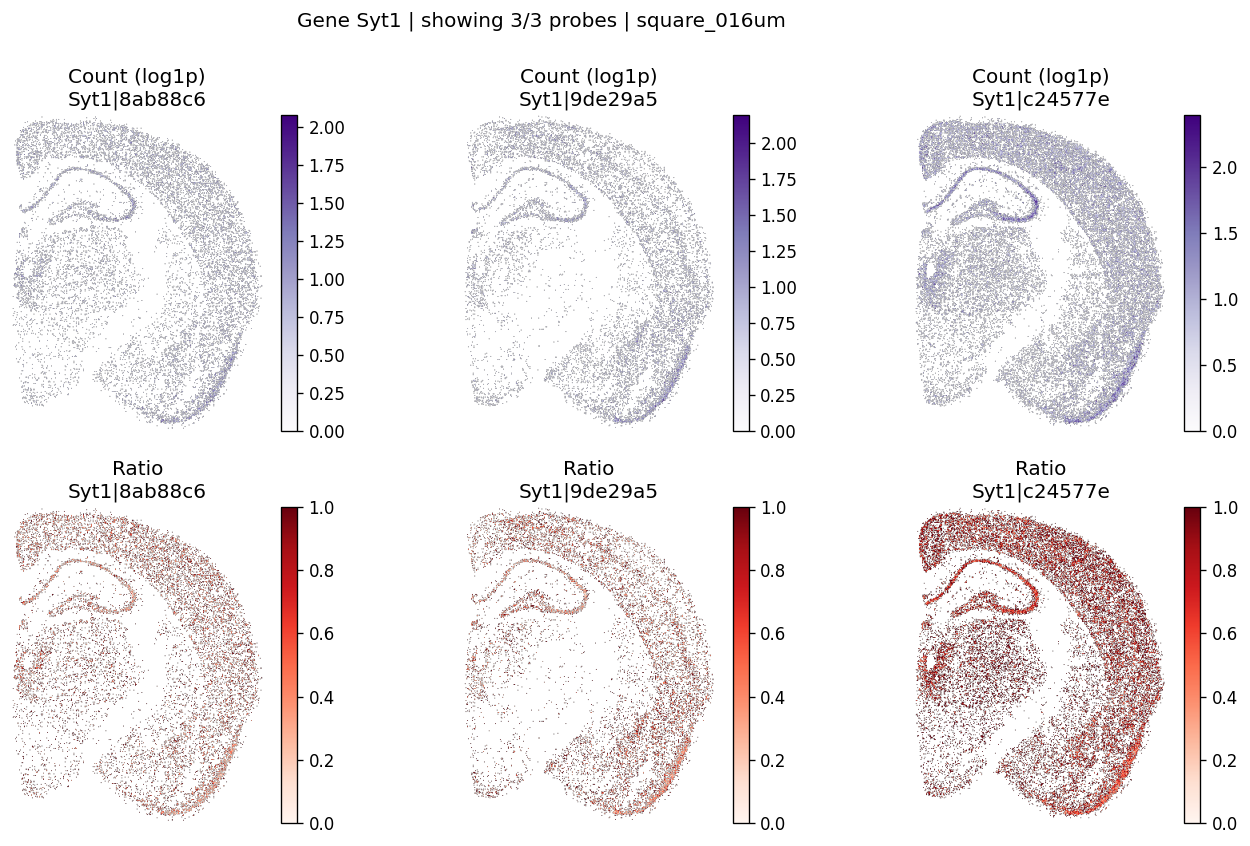

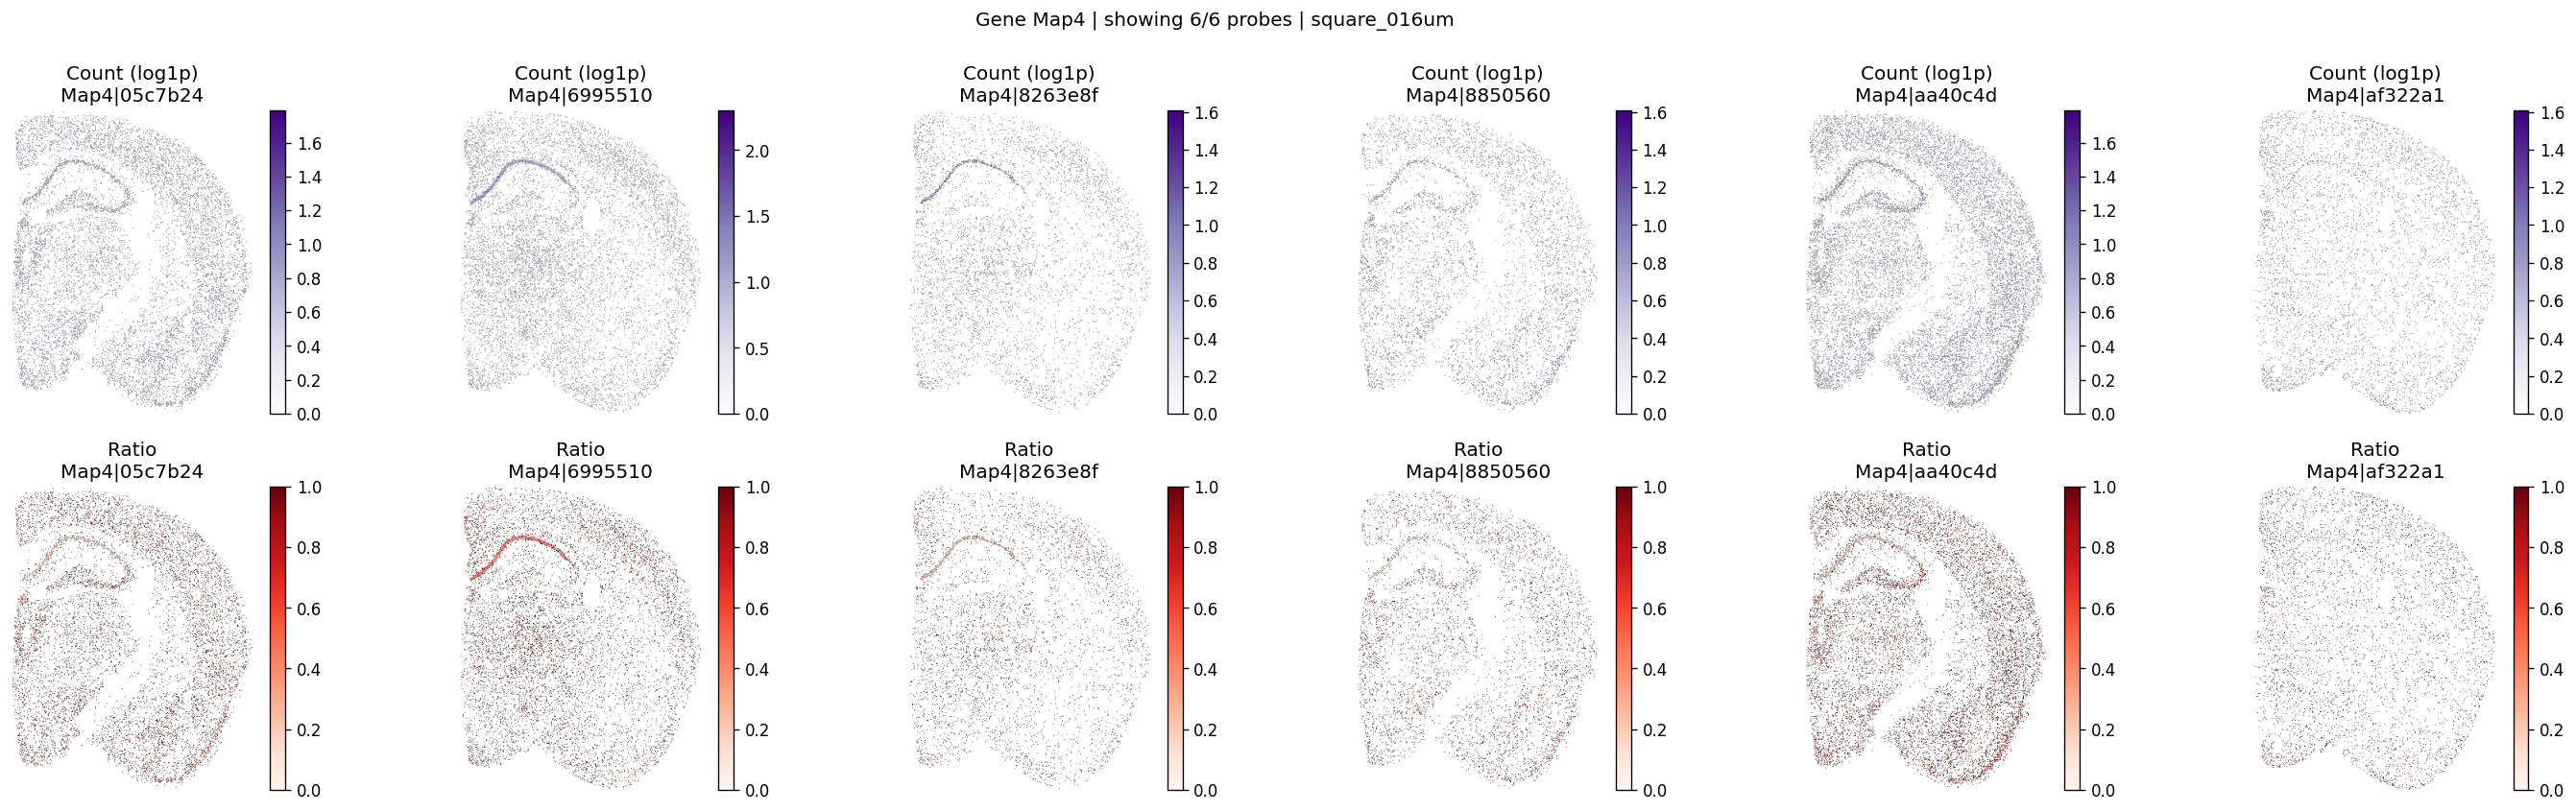

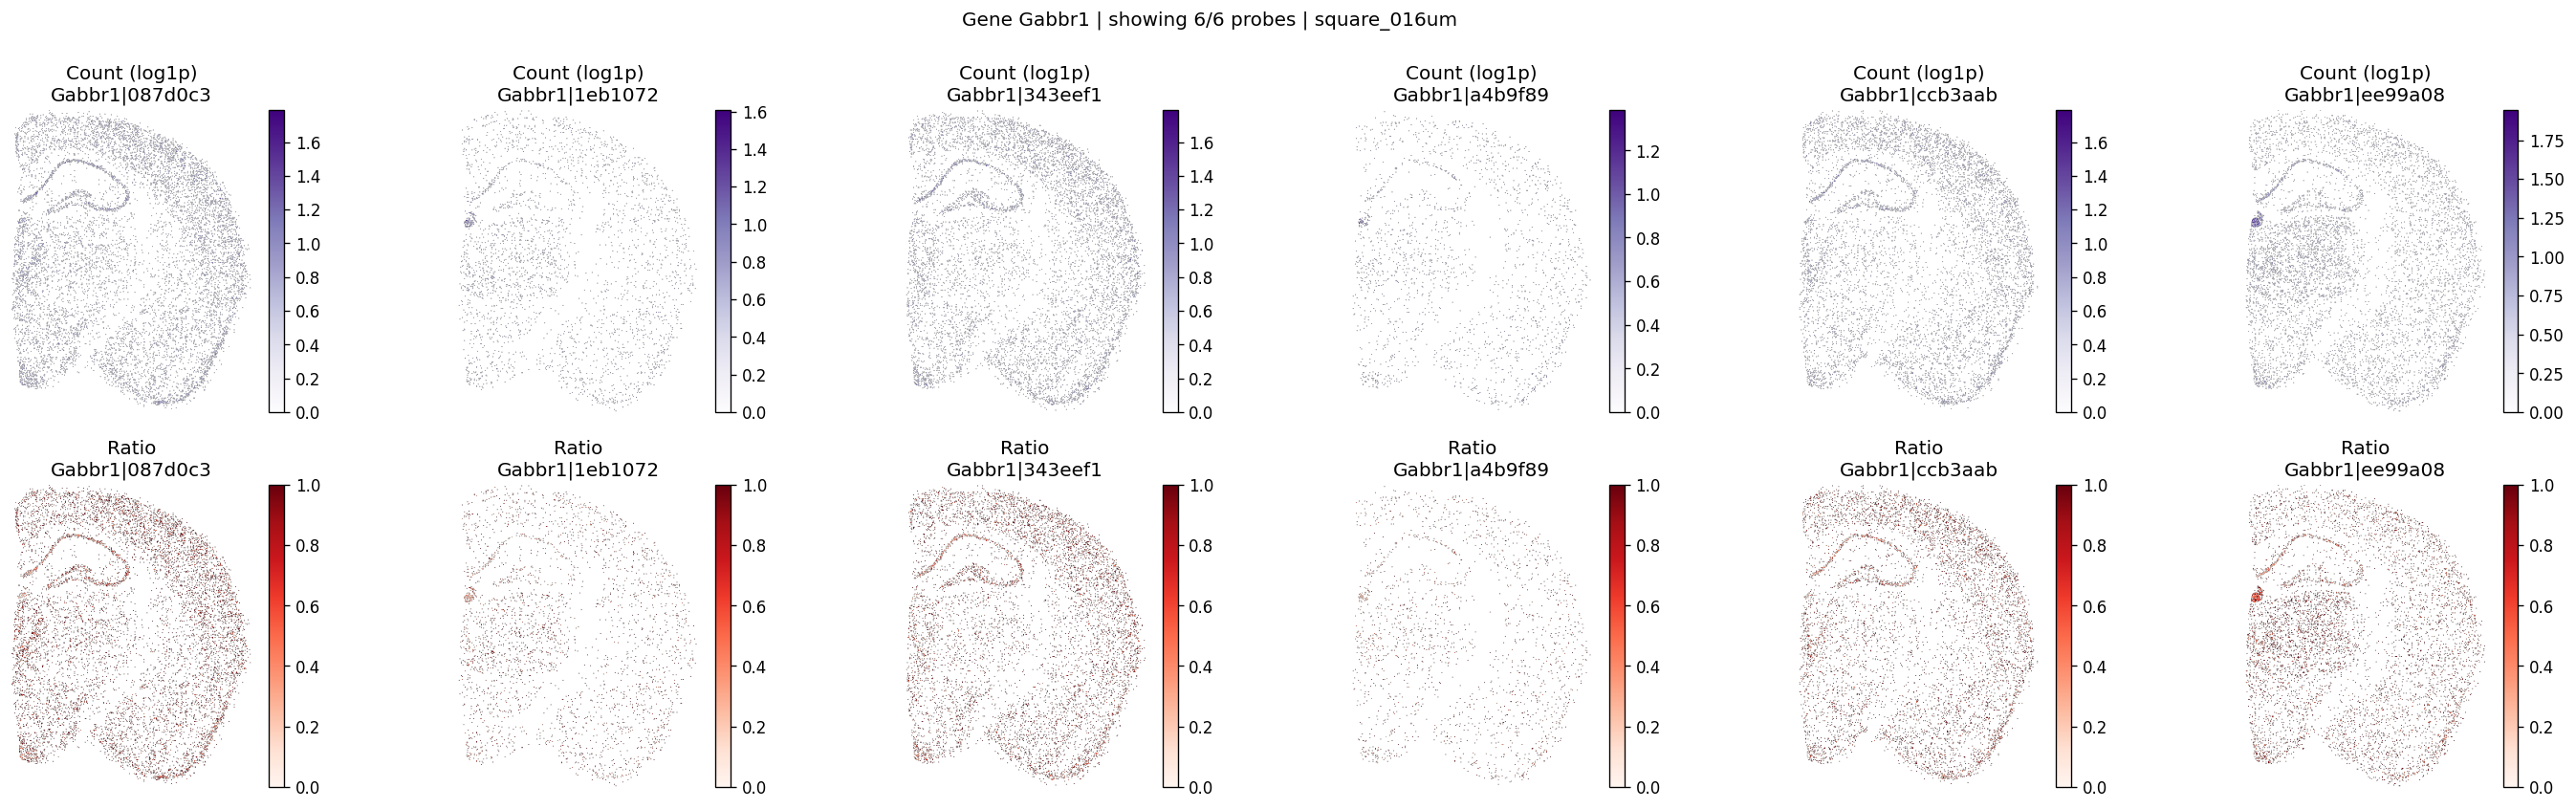

In [20]:
for gene_id in top_genes[:3]:
    plot_gene_probe_maps(
        sdata=sdata,
        bin_table=test_table,
        bin_element=test_bins_element,
        gene_id=gene_id,
        group_col='gene_name',
        max_probes=6,
        probe_meta=probe_meta,
        hide_zero_ratio=True,
    )

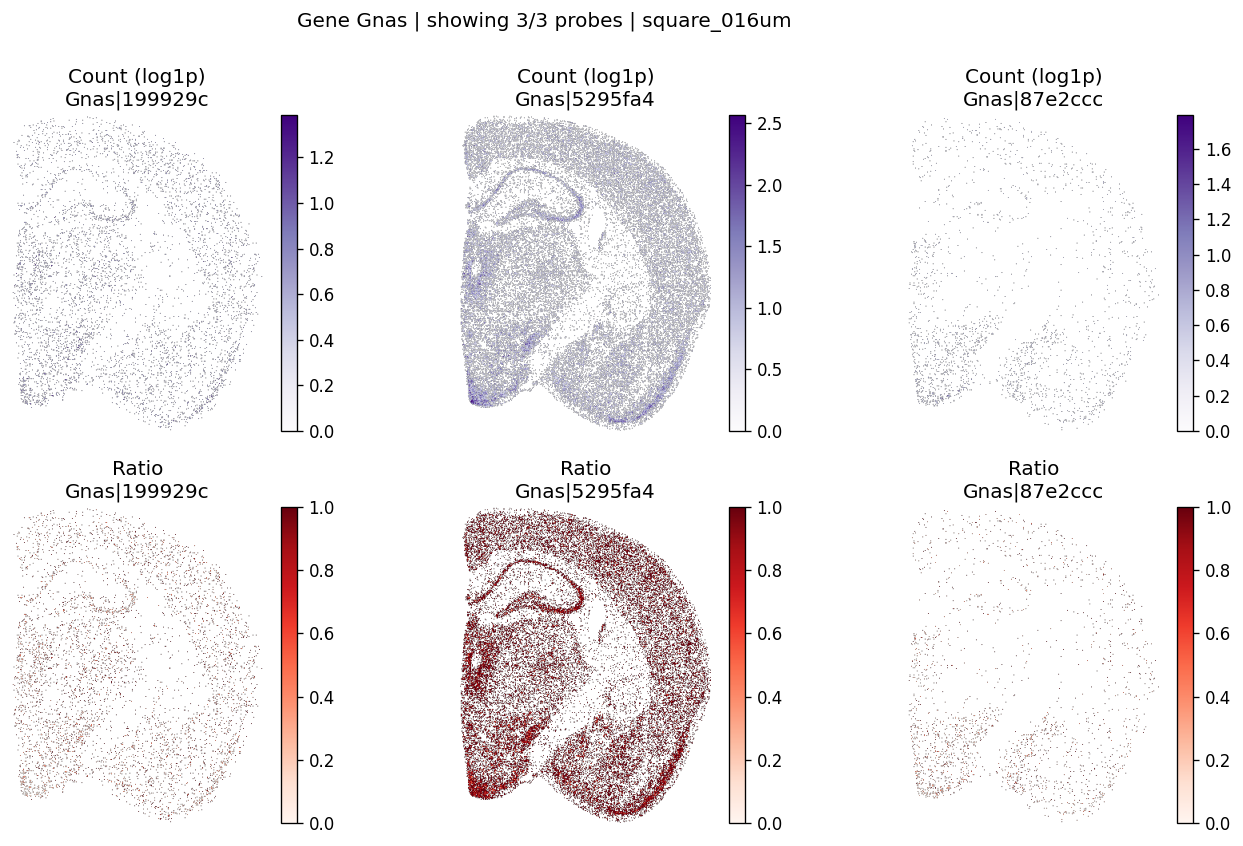

CPU times: user 206 ms, sys: 13.4 ms, total: 219 ms
Wall time: 222 ms


In [21]:
%%time
# Example: inspect a specific gene manually
plot_gene_probe_maps(
    sdata, test_table, test_bins_element, 
    gene_id="Gnas", 
    group_col='gene_name', 
    probe_meta=probe_meta
)

To see the spatially variable transcript regions, we can visualize the 10x reference probe sets along with a matched transcript reference. The following files need to be downloaded and provided as input:
- `Visium_Mouse_Transcriptome_Probe_Set_v2.1.0_GRCm39-2024-A.bed` from [10x Genomics](https://www.10xgenomics.com/support/software/space-ranger/downloads#reference-downloads)
- `gencode.vM33.annotation.gtf.gz` from [GENCODE](https://www.gencodegenes.org/mouse/releases.html)

In [22]:
def plot_probe_transcript_structure(
    gene_name: str,
    bed_file: str | Path,
    gtf_file: str | Path,
    figsize: tuple[float, float] = (12, 6),
):
    """Visualize probe and transcript exon structure for a given gene.

    Reads probe coordinates from a BED12 file and transcript structure from a GTF file,
    then plots them on the same genomic coordinate axis. Each probe is shown on its
    own row to avoid overlap, and transcripts are labeled by transcript_name.
    """
    import gzip

    bed_file = Path(bed_file)
    gtf_file = Path(gtf_file)

    # Read BED12 file and keep block model columns.
    bed_cols = [
        "chrom", "start", "end", "name", "score", "strand",
        "thickStart", "thickEnd", "itemRgb", "blockCount", "blockSizes", "blockStarts",
    ]
    bed_df = pd.read_csv(
        bed_file,
        sep="\t",
        header=None,
        names=bed_cols,
        usecols=list(range(12)),
    )

    # Filter probes by gene name using pipe-delimited match (format: gene_id|gene_name|hash).
    probe_mask = bed_df["name"].astype(str).str.contains(rf"\|{gene_name}\|", case=False, na=False)
    probes = bed_df[probe_mask].copy()

    if probes.empty:
        warnings.warn(f"No probes found for gene '{gene_name}' in {bed_file}")

    # Extract shorter probe labels for common formats.
    def shorten_probe_id(full_name: str) -> str:
        text = str(full_name)
        if "|" in text:
            parts = text.split("|")
            if len(parts) >= 2:
                return "|".join(parts[1:])
        return text

    probes["probe_id"] = probes["name"].apply(shorten_probe_id)

    # Convert BED12 blocks to absolute genomic coordinates per probe.
    def parse_blocks(row: pd.Series) -> list[tuple[int, int]]:
        starts = [int(x) for x in str(row["blockStarts"]).strip(",").split(",") if x != ""]
        sizes = [int(x) for x in str(row["blockSizes"]).strip(",").split(",") if x != ""]
        n = min(int(row["blockCount"]), len(starts), len(sizes))
        blocks = []
        for i in range(n):
            block_start = int(row["start"]) + starts[i]
            block_end = block_start + sizes[i]
            blocks.append((block_start, block_end))
        return blocks

    if not probes.empty:
        probes["blocks"] = probes.apply(parse_blocks, axis=1)

    # Read GTF and filter transcripts by gene name
    if str(gtf_file).endswith(".gz"):
        gtf_opener = lambda f: gzip.open(f, "rt")
    else:
        gtf_opener = open

    transcripts_by_id = {}
    with gtf_opener(gtf_file) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 9:
                continue
            ftype, start, end = fields[2], int(fields[3]), int(fields[4])
            attrs = {}
            for attr in fields[8].split("; "):
                if " " in attr:
                    k, v = attr.split(" ", 1)
                    attrs[k] = v.strip('"')

            # Match gene by gene_name or gene_id
            if attrs.get("gene_name", "").lower() != gene_name.lower() and \
               attrs.get("gene_id", "").lower() != gene_name.lower():
                continue

            tx_id = attrs.get("transcript_id", "unknown")
            if tx_id not in transcripts_by_id:
                tx_name = attrs.get("transcript_name", tx_id)
                transcripts_by_id[tx_id] = {
                    "chrom": fields[0],
                    "strand": fields[6],
                    "tx_name": tx_name,
                    "exons": [],
                }

            if ftype == "exon":
                transcripts_by_id[tx_id]["exons"].append((start, end))

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot transcripts first
    y_pos = 0
    x_mins = []
    x_maxs = []

    # Strand color coding for cleaner direction cues.
    strand_colors = {
        "+": "steelblue",
        "-": "darkorange",
    }

    if transcripts_by_id:
        for tx_id, tx_info in sorted(transcripts_by_id.items()):
            exons = sorted(tx_info["exons"])
            if not exons:
                continue

            # Draw introns (thin line)
            min_coord = min(e[0] for e in exons)
            max_coord = max(e[1] for e in exons)
            x_mins.append(min_coord)
            x_maxs.append(max_coord)
            ax.plot([min_coord, max_coord], [y_pos, y_pos], "k-", linewidth=0.5, alpha=0.5)

            # Draw exons (thick boxes), color by strand
            strand = str(tx_info.get("strand", "."))
            tx_color = strand_colors.get(strand, "gray")
            for start, end in exons:
                ax.barh(y_pos, end - start, left=start, height=0.6, color=tx_color, edgecolor="black")

            # Label with transcript_name
            tx_name = tx_info.get("tx_name", tx_id[:20])
            ax.text(min_coord - (max_coord - min_coord) * 0.05, y_pos, tx_name[:30], ha="right", fontsize=8)
            y_pos += 1

    # Plot probes, each on its own row, using BED12 block segments.
    probe_rows = probes.sort_values(["chrom", "start", "end"]) if not probes.empty else probes

    for idx, (_, row) in enumerate(probe_rows.iterrows()):
        probe_y = y_pos + idx
        blocks = row["blocks"] if isinstance(row["blocks"], list) and row["blocks"] else [(int(row["start"]), int(row["end"]))]
        probe_min = min(b[0] for b in blocks)
        probe_max = max(b[1] for b in blocks)
        x_mins.append(probe_min)
        x_maxs.append(probe_max)

        ax.plot([probe_min, probe_max], [probe_y, probe_y], color="firebrick", linewidth=0.7, alpha=0.6)
        for block_start, block_end in blocks:
            ax.barh(
                probe_y,
                block_end - block_start,
                left=block_start,
                height=0.45,
                color="salmon",
                edgecolor="firebrick",
            )

    x_pad = max(1.0, (max(x_maxs) - min(x_mins)) * 0.02) if x_mins and x_maxs else 1.0

    for idx, (_, row) in enumerate(probe_rows.iterrows()):
        probe_y = y_pos + idx
        blocks = row["blocks"] if isinstance(row["blocks"], list) and row["blocks"] else [(int(row["start"]), int(row["end"]))]
        probe_min = min(b[0] for b in blocks)
        ax.text(probe_min - x_pad, probe_y, row["probe_id"], ha="right", va="center", fontsize=7, color="red")

    y_pos += len(probe_rows)

    # Format axes
    ax.set_ylim(-0.5, y_pos + 0.5)
    ax.set_xlabel("Genomic coordinate (bp)")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_title(f"Probe and transcript structure: {gene_name}")
    ax.grid(True, axis="x", alpha=0.3)

    # Place strand direction note as a single centered row below the plot.
    direction_note = "Transcript 5'->3' direction: + strand left->right (blue) | - strand right->left (orange)"
    fig.text(0.5, 0.01, direction_note, ha="center", va="bottom", fontsize=10, color="black")

    # Reserve bottom margin for the legend row.
    fig.tight_layout(rect=(0.0, 0.05, 1.0, 1.0))
    plt.show()

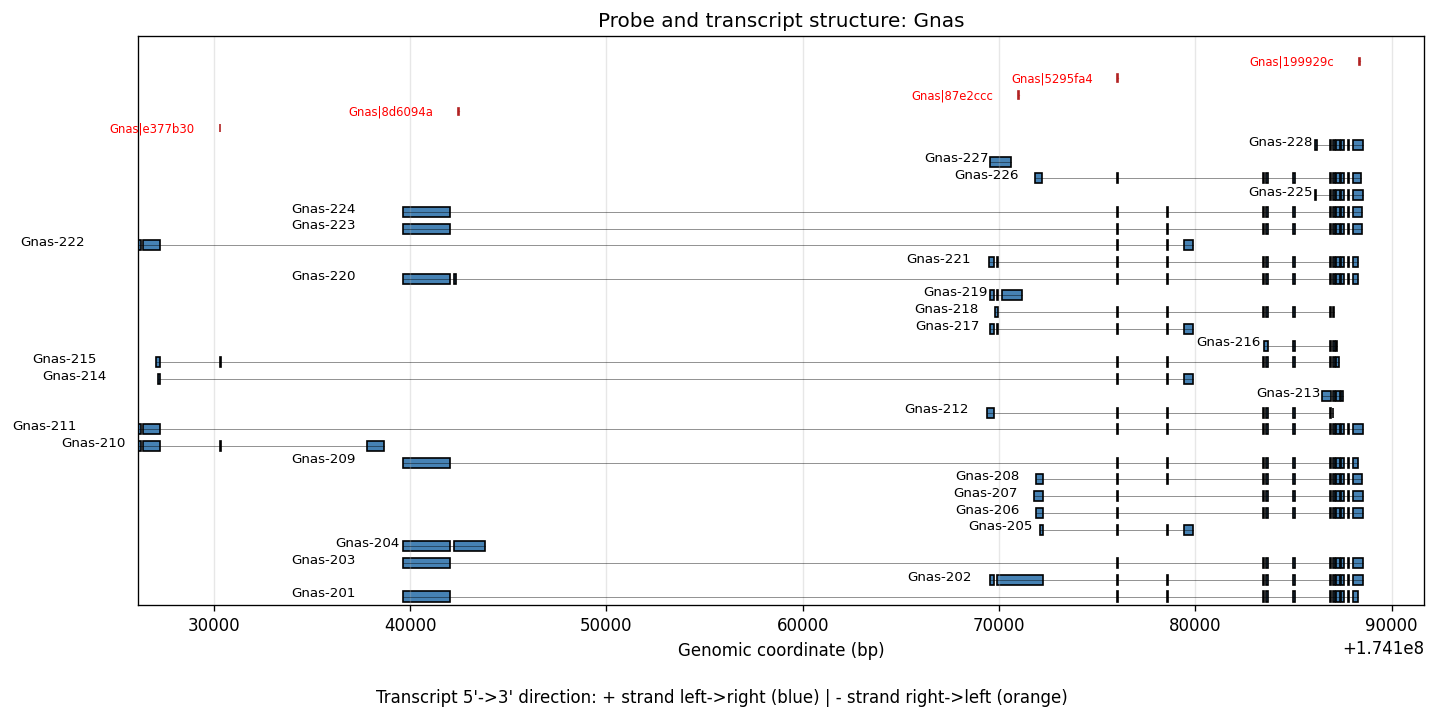

CPU times: user 6.33 s, sys: 38.3 ms, total: 6.37 s
Wall time: 6.4 s


In [23]:
%%time
plot_probe_transcript_structure(
    gene_name="Gnas",
    bed_file=visium_hd_outs / "Visium_Mouse_Transcriptome_Probe_Set_v2.1.0_GRCm39-2024-A.bed",
    gtf_file=reference_path / "gencode.vM33.annotation.gtf.gz",
)

## Advanced analyses

### Spatial resolution comparison

For illustration, we use the top 200 genes from the 16µm analysis as the reference set:

In [24]:
# np.random.seed(42)
# gene_names = sdata.tables[test_table].var['gene_name'].unique()
# gene_subset = np.random.choice(gene_names, size=200, replace=False)
gene_subset = sv_res_16um.sort_values('pvalue').head(200)['gene'].astype(str).tolist()

Run spatial variability tests across all three resolutions:

In [25]:
%%time
# Compare results across 2µm, 8µm, 16µm resolutions
resolutions = [
    {'bin': f'{dataset_id}_square_002um', 'table_name': 'square_002um'},
    {'bin': f'{dataset_id}_square_008um', 'table_name': 'square_008um'},
    {'bin': f'{dataset_id}_square_016um', 'table_name': 'square_016um'},
]

res_results = []
for res in resolutions:
    m = SplisosmFFT(neighbor_degree=1, rho=0.99)
    sdata_subset = sd.filter_by_table_query(
        sdata,
        table_name=res['table_name'],
        var_expr=an.col('gene_name').is_in(gene_subset),
    )
    m.setup_data(
        sdata_subset,
        bins=res['bin'],
        table_name=res['table_name'],
        col_key="array_col",
        row_key="array_row",
        layer="counts",
        group_iso_by="gene_ids",
        gene_names="gene_name",
        min_counts=10,
        min_bin_pct=0.0
    )
    m.test_spatial_variability(method='hsic-ir')
    results = m.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
    results.rename(columns={'pvalue': f"p_{res['table_name']}"}, inplace=True)
    res_results.append(results)

SV [hsic-ir]: 100%|██████████| 23/23 [00:00<00:00, 76.41it/s]


CPU times: user 3min 23s, sys: 2min 22s, total: 5min 45s
Wall time: 1min 25s


In [26]:
merged = res_results[0]
for res in res_results[1:]:
    merged = merged.merge(res, on="gene", how="inner")

p_cols = [c for c in merged.columns if c.startswith("p_")]
print("Spearman correlation across spatial resolutions:")
display(merged[p_cols].corr(method="spearman"))

Spearman correlation across spatial resolutions:


,p_square_002um,p_square_008um,p_square_016um
p_square_002um,1.000000,0.608580,0.510899
p_square_008um,0.608580,1.000000,0.705016
p_square_016um,0.510899,0.705016,1.000000


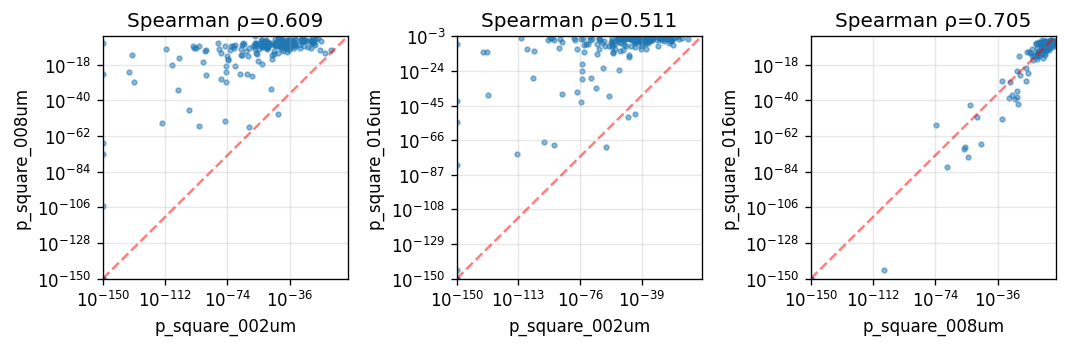

In [27]:
pairs = list(combinations(p_cols, 2))
if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(3 * len(pairs), 3), squeeze=False)
    axes = axes.ravel()

    for ax, (x_col, y_col) in zip(axes, pairs):
        x = merged[x_col].to_numpy()
        y = merged[y_col].to_numpy()
        corr, pval = spearmanr(x, y)

        ax.scatter(x + 1e-150, y + 1e-150, s=8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"Spearman ρ={corr:.3f}")
        ax.grid(True, alpha=0.3)

        low = 1e-150
        high = max(np.max(x), np.max(y))
        ax.plot([low, high], [low, high], "r--", alpha=0.5, linewidth=1.5)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

    plt.tight_layout()
    plt.show()

Gene rankings are broadly consistent across resolutions, especially between 16µm and 8µm. The 2µm analysis shows stronger statistical significance, likely because the kernel places more weight on low-frequency patterns at finer scales.

### Method comparison: `SplisosmFFT` vs `SplisosmNP`

We now compare FFT-accelerated and non-parametric spatial variability tests at 16 µm resolution.

**Note:** Since v1.2.0, `SplisosmNP` SV tests use Liu's approximation from full-rank spatial-kernel cumulants by default. See the [SV hyperparameter optimization notebook](visiumhd_ffpe_svhp.ipynb) for comparison with the legacy low-rank approach.

For large implicit CAR kernels, `null_configs={"n_probes": m}` controls the Hutchinson trace budget. Smaller `m` is faster but noisier. To emphasize broad smooth patterns, prefer increasing `rho` (for example, `rho=0.999`) rather than rank truncation.

In [28]:
%%time
# Run SplisosmNP at 16µm for direct comparison with SplisosmFFT
model_np = SplisosmNP(
    k_neighbors=4,
    rho=0.99,
    standardize_cov=False, # turn off for faster runtime
)
model_np.setup_data(
    adata=sdata.tables[test_table],
    spatial_key='spatial', # adata.obsm key for spatial coordinates
    layer='counts',
    group_iso_by=group_iso_by, # 'gene_ids'
    gene_names=gene_name_col, # 'gene_name'
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True,
    min_component_size=10 # remove disconnected tissue fragments if any
)

CPU times: user 1.64 s, sys: 375 ms, total: 2.02 s
Wall time: 2.07 s


In [29]:
%%time
model_np.test_spatial_variability(
    method='hsic-ir',
    null_configs={"n_probes": 60},
    ratio_transformation='none',
    print_progress=True,
)

SV [hsic-ir]: 100%|██████████| 551/551 [00:20<00:00, 26.55it/s]


CPU times: user 2min 12s, sys: 12.8 s, total: 2min 25s
Wall time: 22.5 s


Compare p-values between `SplisosmFFT` and `SplisosmNP`:

In [30]:
# Extract results and merge
sv_np = model_np.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
sv_np = sv_np.rename(columns={'pvalue': 'pvalue_np'})

comparison = sv_res_16um[['gene', 'pvalue']].copy()
comparison = comparison.rename(columns={'pvalue': 'pvalue_fft'})
comparison = comparison.merge(sv_np, on='gene', how='inner')

corr, _ = spearmanr(comparison['pvalue_fft'], comparison['pvalue_np'])

print(f'Genes tested in both methods: {len(comparison)}')
print(f'== Significant in SplisosmFFT (FDR < 0.01): {(comparison["pvalue_fft"] < 0.01).sum()}')
print(f'== Significant in SplisosmNP (FDR < 0.01): {(comparison["pvalue_np"] < 0.01).sum()}')
print(f'== P-value correlation (Spearman rho): {corr:.4f}')

Genes tested in both methods: 6230
== Significant in SplisosmFFT (FDR < 0.01): 654
== Significant in SplisosmNP (FDR < 0.01): 459
== P-value correlation (Spearman rho): 0.9415


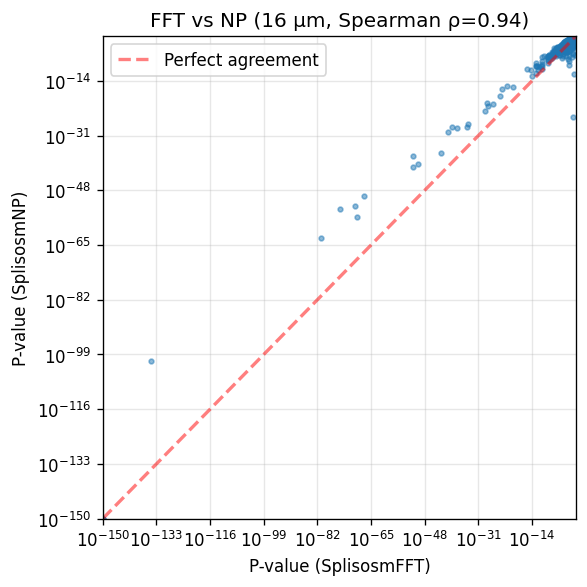

In [31]:
# Scatter plot comparison
fig, ax = plt.subplots(figsize=(5, 5))
x = comparison['pvalue_fft'].to_numpy()
y = comparison['pvalue_np'].to_numpy()

ax.scatter(x + 1e-150, y + 1e-150, s=8, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('P-value (SplisosmFFT)')
ax.set_ylabel('P-value (SplisosmNP)')
ax.set_title(f'FFT vs NP (16 µm, Spearman ρ={corr:.2f})')
ax.grid(True, alpha=0.3)

# Add diagonal reference line
lims = [1e-150, 1.0]
ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect agreement', linewidth=2)
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

### Summary and recommendations

1. Spatial resolution trade-offs:
   - **16 µm**: Fast and reliable — recommended for initial exploration.
   - **8 µm**: High agreement with 16 µm results.
   - **2 µm**: Highest resolution but slower and sparser.

2. `SplisosmFFT` and `SplisosmNP` yield highly concordant rankings on regular grids.

**Recommendations:**

- Start with **16 µm** binning for exploratory analysis; refine with **8 µm** if finer spatial detail is needed.
- Use **SplisosmFFT** on regular grids (Visium HD, Xenium binned data) with `neighbor_degree=1, rho=0.99` as a robust default; use **SplisosmNP** for irregular geometries (e.g., cell-segmented data).

## For reproducibility

In [32]:
import sys
from datetime import date
import splisosm

print("Last updated:", date.today())
print("Python:", sys.version.split()[0])
print("splisosm:", getattr(splisosm, "__version__", "unknown"))

Last updated: 2026-05-03
Python: 3.12.13
splisosm: 1.2.0rc1
